In [1]:
# Histograms of Jaccard scores per arm (4 subplots, one per arm).
# Requires the Libertinus font to be installed to render correctly! (from the paper)
# https://github.com/alerque/libertinus



from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Libertinus Serif', 'Libertinus Math']

PLOTS = Path("plots")
PLOTS.mkdir(exist_ok=True)

root = "data"

records = pd.read_csv(Path("analysis/exp2_mixed_models/recordsWoutiBauti.csv"))
gold_lable = pd.read_csv(PLOTS / "jaccard_gold_labels.csv").set_index("Patient")

CONDITIONS = ["1dAVb", "rbbb", "lbbb", "sb", "af", "st"]
gold_lable["norm"] = (gold_lable[CONDITIONS].sum(axis=1) == 0).astype(int)





In [2]:
import pandas as pd
from database.db_connection import extract_data
import os
from collections import Counter
import itertools

# from exp_statistics.experiment_2.plotii import plot_distribution
# import exp_statistics.experiment_2.jaccard_scores as js
# from exp_statistics.experiment_2.anova import run_anova
# from exp_statistics.experiment_2.lmm import lmm
# import exp_statistics.experiment_2.plot_skew as pl
# from exp_statistics.experiment_2.aggregate_nonparametric import run

results = "exp_statistics/experiment_2"

root = Path("data")
result_dir = Path("results/results")

def get_mapping(dataset):
    return pd.read_csv(root / str(dataset) / "mapping")

def get_questionaire(identifier, dataset):
    return pd.read_csv(result_dir / f"participant_{str(identifier)}_{str(dataset)}" / f"survey_data_participant_{str(identifier)}_{str(dataset)}.csv")

def get_participent_diagnosis(identifier, dataset):
    return pd.read_csv(result_dir / f"participant_{str(identifier)}_{str(dataset)}" / f"diagnosis_participant_{str(identifier)}_{str(dataset)}.csv")





In [3]:
# Group records by participant, arm, and experience level to get mean Jaccard scores
records_trials = records.drop_duplicates(subset=["participant", "patient"]).copy()
records_per_arm = records_trials.groupby(["participant", "arm", "experience_level"])["jaccard"].mean().reset_index()
records_per_arm.groupby(["arm", "experience_level"])["jaccard"].describe()


count      mean       std       min       25%       50%  \
arm experience_level                                                            
0   Expert             17.0  0.703922  0.278857  0.100000  0.600000  0.800000   
    Novice             10.0  0.613333  0.226732  0.200000  0.508333  0.600000   
1   Expert             17.0  0.831373  0.249018  0.000000  0.800000  0.900000   
    Novice             10.0  0.848333  0.177160  0.433333  0.787500  0.850000   
2   Expert             17.0  0.649020  0.176430  0.200000  0.600000  0.666667   
    Novice             10.0  0.813333  0.164204  0.566667  0.675000  0.833333   
3   Expert             17.0  0.774510  0.167717  0.300000  0.700000  0.800000   
    Novice             10.0  0.838333  0.131480  0.600000  0.762500  0.850000   

                        75%  max  
arm experience_level              
0   Expert            0.900  1.0  
    Novice            0.775  1.0  
1   Expert            1.000  1.0  
    Novice            1.000  1.0  
2   Expert            0.800  0.9  
    Novice            0.975  1.0  
3   Expert            0.800  1.0  
    Novice            0.925  1.0

In [4]:
# 2x2 Factorial Split Violin Plots (Novices on Left, Experts on Right)
from matplotlib.patches import Patch

COLOR_NOVICE = "#507D9E"  # Steel Blue for Novice
COLOR_EXPERT = "#DA627D"  # Rose for Expert
COLOR_BORDER = "#0C0C0C"
COLOR_DARK_TEXT = "#1E293B"
COLOR_GRID = "#CFD8DC"

palette = {"Novice": COLOR_NOVICE, "Expert": COLOR_EXPERT}

def plot_2x2_violin_distribution(df, output_path=PLOTS / "jaccard_arm_violins.pdf", bw_adjust=0.5):
    fig, axes = plt.subplots(2, 2, figsize=(6.8, 6.2), sharey=True)
    fig.patch.set_facecolor("#FFFFFF")

    arm_names = [
        "Baseline (Arm 0)",
        "Arm 1\n(AI Prediction)",
        "Arm 2\n(Reference Case)",
        "Arm 3\n(AI Prediction & Reference Case)"
    ]

    for idx, (ax, a) in enumerate(zip(axes.flat, range(4))):
        sub_df = df[df["arm"] == a]
        ax.grid(axis="y", color=COLOR_GRID, zorder=0, linewidth=0.8, alpha=1, linestyle="-")

        sns.violinplot(
            data=sub_df,
            x=[""] * len(sub_df),
            y="jaccard",
            hue="experience_level",
            hue_order=["Novice", "Expert"],
            split=True,
            palette=palette,
            inner=None,
            cut=0,
            bw_adjust=bw_adjust,
            linewidth=1.1,
            width=0.74,
            ax=ax,
            zorder=2
        )

        ax.set_title(arm_names[a], fontsize=10.5, fontweight="bold", pad=7, color=COLOR_DARK_TEXT)
        ax.set_xlabel("")
        ax.set_ylabel("Jaccard score" if idx % 2 == 0 else "", fontsize=9.5, color=COLOR_DARK_TEXT)
        ax.set_xlim(-0.46, 0.46)
        ax.set_ylim(-0.03, 1.03)
        ax.set_yticks(np.arange(0, 1.1, 0.2))
        ax.set_yticklabels([f"{y:.1f}" for y in np.arange(0, 1.1, 0.2)], fontsize=8.5, color=COLOR_DARK_TEXT)
        ax.tick_params(left=True, bottom=False, labelbottom=False, color=COLOR_BORDER, length=3)

        for spine in ax.spines.values():
            spine.set_color(COLOR_BORDER)

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    legend_elements = [
        Patch(facecolor=COLOR_NOVICE, edgecolor="black", label="Lower exposure means (Left)"),
        Patch(facecolor=COLOR_EXPERT, edgecolor="black", label="High exposure means (Right)")
    ]
    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        frameon=False,
        fontsize=9.5
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.91)

    if output_path:
        out_p = Path(output_path)
        plt.savefig(out_p, bbox_inches="tight")
        if out_p.suffix.lower() == ".pdf":
            plt.savefig(out_p.with_suffix(".png"), dpi=300, bbox_inches="tight")
    plt.show()



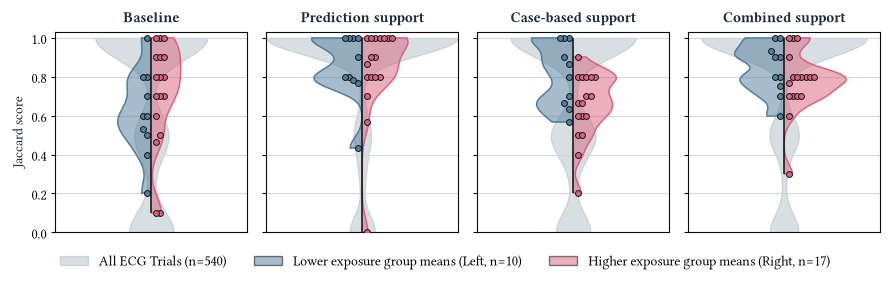

In [7]:
# 2x2 Factorial Split Violins (Left: Novice, Right: Expert from Participant Means) with Background Symmetrical Violin (All Trials)
import scipy.stats as stats
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

COLOR_NOVICE = "#507D9E"  # Steel Blue for Novice
COLOR_EXPERT = "#DA627D"  # Rose for Expert
COLOR_BORDER = "#0C0C0C"
COLOR_DARK_TEXT = "#1E293B"
COLOR_GRID = "#CFD8DC"
COLOR_COMBINED_BG = "#ECEFF1"  # Light neutral for combined background violin
COLOR_COMBINED_EDGE = "#90A4AE"

def compute_half_swarm_x(vals, pos=0.85, side='left', drop_start=0.04, dot_spacing=0.038, min_dist_y=0.035):
    """Compute x coordinates for droplets inside one half of the split violin."""
    sorted_indices = np.argsort(vals)
    sorted_vals = np.array(vals)[sorted_indices]

    placed_slots = {}
    slots_assigned = np.zeros(len(vals), dtype=int)

    for i, y in enumerate(sorted_vals):
        k = 0
        while True:
            if k not in placed_slots:
                placed_slots[k] = [y]
                slots_assigned[i] = k
                break
            collision = any(abs(y - existing_y) < min_dist_y for existing_y in placed_slots[k])
            if not collision:
                placed_slots[k].append(y)
                slots_assigned[i] = k
                break
            k += 1

    original_slots = np.zeros(len(vals), dtype=int)
    original_slots[sorted_indices] = slots_assigned

    if side == 'left':
        x_pts = pos - drop_start - original_slots * dot_spacing
    else:
        x_pts = pos + drop_start + original_slots * dot_spacing
    return x_pts

def get_global_max_densities(df_participant, df_trials, bw_adjust_fg=0.5, bw_adjust_bg=0.25):
    """Plot the global maximum KDE densities across all 4 subplots for uniform scaling."""
    max_bg = 0.0
    max_fg = 0.0
    for a in range(4):
        # Background: all individual ECG trials
        sub_trials = df_trials[df_trials['arm'] == a]
        trial_vals = sub_trials['jaccard'].values
        if len(np.unique(trial_vals)) > 1:
            kde_bg = stats.gaussian_kde(trial_vals, bw_method='scott')
            kde_bg.set_bandwidth(kde_bg.factor * bw_adjust_bg)
            y_grid = np.linspace(trial_vals.min(), trial_vals.max(), 200)
            max_bg = max(max_bg, kde_bg(y_grid).max())

        # Foreground: participant means per novice / expert
        sub_part = df_participant[df_participant['arm'] == a]
        nov_vals = sub_part.loc[sub_part['experience_level'] == 'Novice', 'jaccard'].values
        if len(np.unique(nov_vals)) > 1:
            kde_n = stats.gaussian_kde(nov_vals, bw_method='scott')
            kde_n.set_bandwidth(kde_n.factor * bw_adjust_fg)
            y_grid_n = np.linspace(nov_vals.min(), nov_vals.max(), 200)
            max_fg = max(max_fg, kde_n(y_grid_n).max())

        exp_vals = sub_part.loc[sub_part['experience_level'] == 'Expert', 'jaccard'].values
        if len(np.unique(exp_vals)) > 1:
            kde_e = stats.gaussian_kde(exp_vals, bw_method='scott')
            kde_e.set_bandwidth(kde_e.factor * bw_adjust_fg)
            y_grid_e = np.linspace(exp_vals.min(), exp_vals.max(), 200)
            max_fg = max(max_fg, kde_e(y_grid_e).max())

    return max_bg, max_fg

def draw_background_violin(ax, vals, center=0.85, max_half_width=0.85, global_max_dens=1.0, bw_adjust=0.25, color=COLOR_COMBINED_EDGE, edgecolor=COLOR_COMBINED_EDGE):
    """Draw a full symmetrical background violin of all ECG trial Jaccards"""
    vals = np.asarray(vals)
    if len(vals) == 0:
        return
    y_min, y_max = vals.min(), vals.max()
    if len(np.unique(vals)) > 1:
        kde = stats.gaussian_kde(vals, bw_method='scott')
        kde.set_bandwidth(kde.factor * bw_adjust)
        y_grid = np.linspace(y_min, y_max, 200)
        dens = kde(y_grid)
        w = (dens / global_max_dens) * max_half_width

        ax.fill_betweenx(y_grid, center - w, center + w, facecolor=color, alpha=0.35, zorder=1, edgecolor=edgecolor, linewidth=0.9)
    else:
        ax.hlines(y_min, center - max_half_width, center + max_half_width, color=color, alpha=0.35, linewidth=4, zorder=1)

def draw_split_violin_with_inside_droplets(ax, nov_vals, exp_vals, center=0.85, half_width=0.55, global_max_dens=1.0, bw_adjust=0.5, dot_spacing=0.038, dot_size=18):
    """Draw single split violin with novice / expert jaccard averages."""
    nov_vals = np.asarray(nov_vals)
    exp_vals = np.asarray(exp_vals)

    # Left half: novice
    if len(nov_vals) > 0:
        y_min_n, y_max_n = nov_vals.min(), nov_vals.max()
        if len(np.unique(nov_vals)) > 1:
            kde_n = stats.gaussian_kde(nov_vals, bw_method='scott')
            kde_n.set_bandwidth(kde_n.factor * bw_adjust)
            y_grid_n = np.linspace(y_min_n, y_max_n, 200)
            dens_n = kde_n(y_grid_n)
            w_n = (dens_n / global_max_dens) * half_width

            ax.fill_betweenx(y_grid_n, center - w_n, center, facecolor=COLOR_NOVICE, alpha=0.5, zorder=2, edgecolor='none')
            ax.plot(center - w_n, y_grid_n, color=COLOR_NOVICE, linewidth=1.1, zorder=3)
            ax.hlines([y_min_n, y_max_n], [center - w_n[0], center - w_n[-1]], center, color=COLOR_NOVICE, linewidth=1.1, zorder=3)

        x_pts_n = compute_half_swarm_x(nov_vals, pos=center, side='left', drop_start=0.04, dot_spacing=dot_spacing, min_dist_y=0.035)
        ax.scatter(x_pts_n, nov_vals, facecolor=COLOR_NOVICE, edgecolors=COLOR_BORDER, s=dot_size, linewidth=0.7, alpha=0.95, zorder=6)

    # Right half: expert
    if len(exp_vals) > 0:
        y_min_e, y_max_e = exp_vals.min(), exp_vals.max()
        if len(np.unique(exp_vals)) > 1:
            kde_e = stats.gaussian_kde(exp_vals, bw_method='scott')
            kde_e.set_bandwidth(kde_e.factor * bw_adjust)
            y_grid_e = np.linspace(y_min_e, y_max_e, 200)
            dens_e = kde_e(y_grid_e)
            w_e = (dens_e / global_max_dens) * half_width

            ax.fill_betweenx(y_grid_e, center, center + w_e, facecolor=COLOR_EXPERT, alpha=0.5, zorder=2, edgecolor='none')
            ax.plot(center + w_e, y_grid_e, color=COLOR_EXPERT, linewidth=1.1, zorder=3)
            ax.hlines([y_min_e, y_max_e], center, [center + w_e[0], center + w_e[-1]], color=COLOR_EXPERT, linewidth=1.1, zorder=3)

        x_pts_e = compute_half_swarm_x(exp_vals, pos=center, side='right', drop_start=0.04, dot_spacing=dot_spacing, min_dist_y=0.035)
        ax.scatter(x_pts_e, exp_vals, facecolor=COLOR_EXPERT, edgecolors=COLOR_BORDER, s=dot_size, linewidth=0.7, alpha=0.95, zorder=6)

    # 3. Center dividing spine
    all_y = np.concatenate([nov_vals, exp_vals])
    y_min_all, y_max_all = all_y.min(), all_y.max()
    ax.vlines(center, y_min_all, y_max_all, color=COLOR_BORDER, linewidth=1.1, zorder=4)

def plot_2x2_split_violin_distribution(df_participant=records_per_arm, df_trials=records_trials, output_path=PLOTS / "jaccard_arm_split_violins.pdf", bw_adjust_fg=0.5, bw_adjust_bg=0.25, dot_label="Participant Mean"):
    fig, axes = plt.subplots(1, 4, figsize=(9, 2.5), sharey=True)
    fig.patch.set_facecolor("#FFFFFF")

    arm_names = [
        "Baseline",
        "Prediction support",
        "Case-based support",
        "Combined support"
    ]

    center_pos = 0.85
    y_min = 0
    sample_counts = {'Novice': 0, 'Expert': 0, 'Trials': 0}

    # Precompute global density scales across all 4 subplots
    max_bg, max_fg = get_global_max_densities(df_participant, df_trials, bw_adjust_fg=bw_adjust_fg, bw_adjust_bg=bw_adjust_bg)

    for idx, (ax, a) in enumerate(zip(axes.flat, range(4))):
        sub_part = df_participant[df_participant["arm"] == a]
        sub_trials = df_trials[df_trials["arm"] == a]
        ax.grid(axis="y", color=COLOR_GRID, zorder=0, linewidth=0.8, alpha=1, linestyle="-")

        trial_vals = sub_trials["jaccard"].values
        nov_vals = sub_part.loc[sub_part["experience_level"] == "Novice", "jaccard"].values
        exp_vals = sub_part.loc[sub_part["experience_level"] == "Expert", "jaccard"].values
        sample_counts['Novice'] = len(nov_vals)
        sample_counts['Expert'] = len(exp_vals)
        sample_counts['Trials'] = len(trial_vals)

        # 1. Background: All ECG evaluations / trials in this arm (df_trials)
        draw_background_violin(ax, trial_vals, center=center_pos, max_half_width=0.85, global_max_dens=max_bg, bw_adjust=bw_adjust_bg)

        # 2. Foreground: Participant Means per Novice / Expert (df_participant)
        draw_split_violin_with_inside_droplets(ax, nov_vals, exp_vals, center=center_pos, half_width=0.55, global_max_dens=max_fg, bw_adjust=bw_adjust_fg)

        ax.set_title(arm_names[a], fontsize=10.5, fontweight="bold", pad=7, color=COLOR_DARK_TEXT)
        ax.set_xlabel("")
        ax.set_ylabel("Jaccard score" if idx == 0 else "", fontsize=10, color=COLOR_DARK_TEXT)
        ax.set_xlim(0.0, 1.70)
        #ax.set_xticks([0.45, 1.25])
        ax.set_xticks([])
        ax.tick_params(axis='x', which='minor', length=0, width=0)
        ax.tick_params(axis='x', which='major', length=0, width=0)
        #ax.set_xticklabels(["Novice", "Expert"], fontsize=9.5, fontweight="bold", color=COLOR_DARK_TEXT)
        ax.set_ylim(y_min, 1.03)
        ax.tick_params(left=True, bottom=True, color=COLOR_BORDER, length=3)

        for spine in ax.spines.values():
            spine.set_color(COLOR_BORDER)

    n_novice = sample_counts['Novice']
    n_expert = sample_counts['Expert']
    n_trials = (n_novice + n_expert) * 20
    legend_elements = [
        Patch(facecolor=COLOR_COMBINED_EDGE, edgecolor=COLOR_COMBINED_EDGE, alpha=0.35, label=f"All ECG Trials (n={n_trials})"),
        Patch(facecolor=COLOR_NOVICE, edgecolor='black', alpha=0.5, label=f"Lower exposure group means (Left, n={n_novice})"),
        Patch(facecolor=COLOR_EXPERT, edgecolor='black', alpha=0.5, label=f"Higher exposure group means (Right, n={n_expert})"),
        #Line2D([0], [0], marker='o', color='w', markerfacecolor='#94A3B8', markeredgecolor=COLOR_BORDER, markersize=5.5, label=dot_label)
    ]
    fig.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=3,
        frameon=False,
        fontsize=10.0
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)

    if output_path:
        out_p = Path(output_path)
        plt.savefig(out_p, bbox_inches="tight")
        if out_p.suffix.lower() == ".pdf":
            plt.savefig(out_p.with_suffix(".png"), dpi=300, bbox_inches="tight")
    plt.show()
    return sample_counts

# Combined plot: Participant-level means foreground + Trial-level all records background
sample_counts = plot_2x2_split_violin_distribution(df_participant=records_per_arm, df_trials=records_trials, output_path=PLOTS / "jaccard_arm_split_violins.pdf", bw_adjust_fg=0.5, bw_adjust_bg=0.7, dot_label="Participant Mean")
